# CNN Assignment — MNIST Digit Recognition
**Author:** Mayuresh Khedkar

This notebook builds a convolutional neural network using TensorFlow and Keras to classify handwritten digits from the MNIST dataset.  


# Importing the Required Libraries

In [ ]:
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Loading and preprocessiong the dataset

In [ ]:

(x_train, y_train), (x_test, y_test) = mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:

x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255
x_test  = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255


In [ ]:

y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)


In [ ]:

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

x_train shape: (60000, 28, 28, 1)
y_train shape: (60000, 10)


# Building the CNN Architechure

In [ ]:
model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))

In [ ]:
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

# Compiling and training the model(12 Epochs)


In [ ]:
# Compile with cross-entropy loss and Adam optimizer
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# # Train for 12 epochs, 10% of train data used for validation
# history = model.fit(
#     x_train, y_train,
#     batch_size=128,
#     epochs=12,
#     validation_split=0.1
# )
from tensorflow.keras.callbacks import EarlyStopping

# Define the callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,          # Stop if no improvement for 3 epochs
    restore_best_weights=True
)

# Train the model with the callback
history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=50,           # Set higher; EarlyStopping will handle the rest
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.8774 - loss: 0.3895 - val_accuracy: 0.9787 - val_loss: 0.0688
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9600 - loss: 0.1333 - val_accuracy: 0.9872 - val_loss: 0.0457
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9694 - loss: 0.0998 - val_accuracy: 0.9868 - val_loss: 0.0387
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9749 - loss: 0.0825 - val_accuracy: 0.9898 - val_loss: 0.0350
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9781 - loss: 0.0721 - val_accuracy: 0.9903 - val_loss: 0.0336
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9816 - loss: 0.0621 - val_accuracy: 0.9900 - val_loss: 0.0308
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9828 - loss: 0.0574 - val_accuracy: 0.9907 - val_loss: 0.0321
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9842 - loss: 0.0514 - val_accuracy: 

# Evaluated the Test loss and accuraccy.

In [ ]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9926 - loss: 0.0222
Test Loss: 0.0222
Test Accuracy: 0.9926


# Visualised the progress

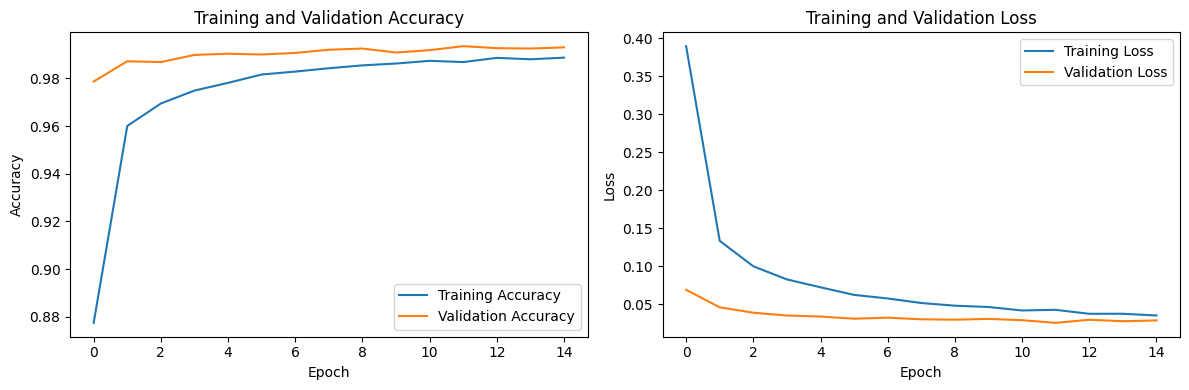

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Summary of Training

The model learned well and gave good results.  
Accuracy increased to more than 98%.  
Loss became very low and stayed stable.  
Training and validation lines are close, so the model works nicely on new data.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

save_folder = '/content/drive/MyDrive/CnnModel/'
if not os.path.exists(save_folder):
    os.makedirs(save_folder)

save_path = os.path.join(save_folder, '15epochs.h5') # Changed to .h5 format
model.save(save_path)